## Figure 5 - Single cell examples

Single-cell example plots extracted from `figure_5_main` (everything *except* the
composite-figure Panel A assembly). Includes: matched-ROI + coding-score examples,
the candidate-cell ranking / kernel inspection, the coding-score barplot with
image-response inset (Panel A variant), and the un-normalized-dropout diagnostic.

Run the imports + data-loading cells first, then any example section.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 1})

# Visual behavior analysis package functions
import visual_behavior.visualization.utils as utils
import visual_behavior.data_access.loading as loading
import visual_behavior.data_access.utilities as utilities

# Clustering modules
from visual_behavior.dimensionality_reduction.clustering import plotting
from visual_behavior.dimensionality_reduction.clustering import processing

# Platform paper figure functions
import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse
import visual_behavior.visualization.ophys.summary_figures as sf

%load_ext autoreload
%autoreload 2
%matplotlib inline

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/traitlets/traitlets.p

In [2]:
# Figure saving
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_5')
os.makedirs(save_dir, exist_ok=True)

## Data Loading

#### Metadata tables

In [3]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# Relevant IDs
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
cell_types = utils.get_cell_types()
experience_levels = utils.get_experience_levels()
palette = utils.get_experience_level_colors()


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

#### Clustering results, coding scores, UMAP

In [4]:
glm_results_dir = loading.get_glm_results_dir()
clustering_dir = loading.get_clustering_results_dir()
data_dir = loading.get_clustering_results_dir()

# Load clustering results
feature_matrix = pd.read_hdf(os.path.join(data_dir, 'clustering_feature_matrix.h5'), key='df')
feature_matrix = feature_matrix.rename(columns={'all-images': 'images', 'behavioral': 'behavior'})

n_clusters = 14
cluster_meta = pd.read_hdf(os.path.join(data_dir, f'cluster_metadata_{n_clusters}_clusters.h5'), key='df')

original_feature_matrix = feature_matrix.copy()
original_cluster_meta = cluster_meta.copy()

# Load coding scores - normalized for clustering
results_pivoted = pd.read_hdf(os.path.join(glm_results_dir, 'across_session_normalized_platform_results_pivoted.h5'), key='df')
all_results = pd.read_hdf(os.path.join(glm_results_dir, 'all_results.h5'), key='df')

# Load UMAP results
umap_df = processing.get_umap_results(feature_matrix, cluster_meta, save_dir=clustering_dir, suffix='')

loading umap results from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_clustering_results/umap_results_df.h5


#### Multi-Session Dataframes

In [5]:
# Data type configuration
data_type = 'events'
interpolate = True
output_sampling_rate = 30
inclusion_criteria = 'platform_experiment_table'


conditions = ['cell_specimen_id', 'is_change']
multi_session_df = loading.get_multi_session_df_for_conditions(
    data_type,
    event_type='all',
    conditions=conditions,
    inclusion_criteria=inclusion_criteria,
    interpolate=interpolate,
    output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

# Separate into change and non-change responses
change_mdf = multi_session_df[multi_session_df.is_change == True]
change_mdf = change_mdf.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')

image_mdf = multi_session_df[multi_session_df.is_change == False]
image_mdf = image_mdf.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')

# Omission responses
conditions = ['cell_specimen_id', 'omitted']
omission_mdf = loading.get_multi_session_df_for_conditions(
    data_type,
    event_type='all',
    conditions=conditions,
    inclusion_criteria=inclusion_criteria,
    interpolate=interpolate,
    output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

omission_mdf = omission_mdf[omission_mdf.omitted == True]
omission_mdf = omission_mdf.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')

# Remove outliers
threshold_percentile = 99.9  # for removing outliers for pl
image_mdf, image_outliers = processing.remove_outliers(image_mdf, threshold_percentile)
change_mdf, change_outliers = processing.remove_outliers(change_mdf, threshold_percentile)
omission_mdf, omission_outliers = processing.remove_outliers(omission_mdf, threshold_percentile)

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_is_change_platform_experiment_table.feather
there are 1881 experiments in the full multi_session_df
there are 400 experiments in the multi_session_df after limiting to platform experiments
there are 400 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_omitted_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_omitted_platform_experiment_table.feather
there are 1879 experiments in the full multi_session_df
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table


#### Example cell used by the Panel A variant section below

In [6]:
# A_CELL is defined inside the composite cell in figure_5_main; set it here so the
# Panel A variant cells below are runnable on their own.
A_CELL = 1086620671


## Single cell examples
Matched ROI masks + coding scores (and change/omission responses) for example cells.

cell_specimen_id: 1086514606
experience_level: Familiar
ophys_experiment_id: 989213060


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel
ophys_experiment_id: 990400778


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel +
ophys_experiment_id: 991852002


...

experience_level: Novel
ophys_experiment_id: 990400778


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is 

experience_level: Novel +
ophys_experiment_id: 991852002


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is 

saving plot for 1086514606
saved


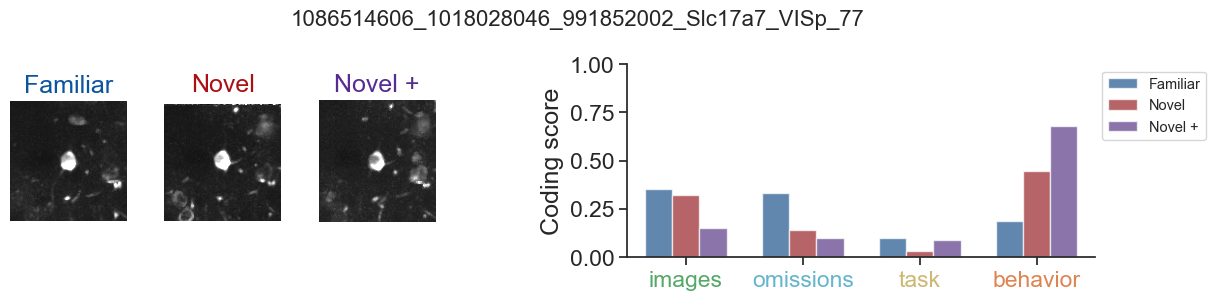

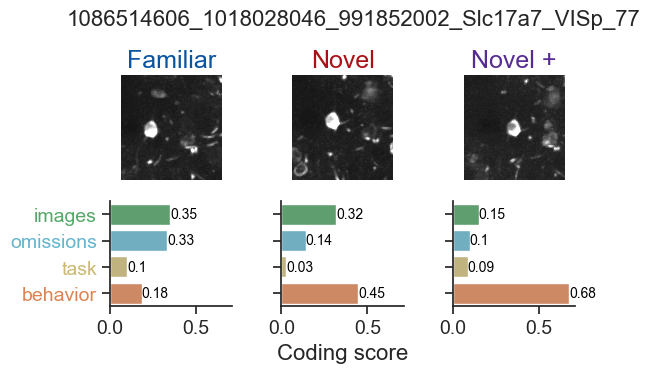

In [7]:
# cell_specimen_id = 1086515505
cell_specimen_id = 1086514606 #Excitatory behavior coding cell

cell_metadata = platform_cells_table[platform_cells_table.cell_specimen_id == cell_specimen_id]
cell_dropouts = results_pivoted[results_pivoted.cell_specimen_id==cell_specimen_id][processing.get_features_for_clustering()+['experience_level']]

# Load change and omission response dataframes for example cell
change_mdf_example = change_mdf[change_mdf.cell_specimen_id == cell_specimen_id]
omission_mdf_example = omission_mdf[omission_mdf.cell_specimen_id == cell_specimen_id]

# Plot matched ROI and coding scores
pse.plot_matched_roi_and_coding_scores(cell_metadata, cell_dropouts, platform_experiments, 
                                       save_dir=save_dir)
pse.plot_matched_roi_and_coding_scores_for_experience_levels(cell_metadata, cell_dropouts, platform_experiments, 
                                       save_dir=save_dir)

# # Plot cell change and omission responses
# pse.plot_cell_change_and_omission_responses(
#     change_mdf_example,
#     omission_mdf_example,
#     cell_specimen_id,
#     save_dir=save_dir)

cell_specimen_id: 1086620671
experience_level: Familiar
ophys_experiment_id: 956941846


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel
ophys_experiment_id: 957759566


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel +
ophys_experiment_id: 960410028


...

experience_level: Novel
ophys_experiment_id: 957759566


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is 

experience_level: Novel +
ophys_experiment_id: 960410028


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is 

saving plot for 1086620671
saved


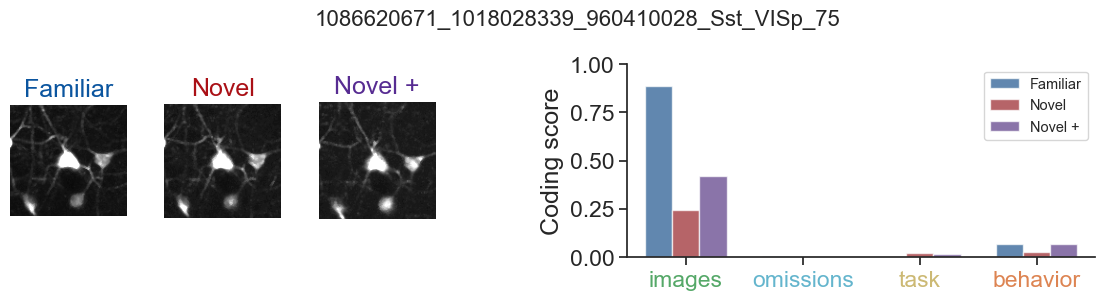

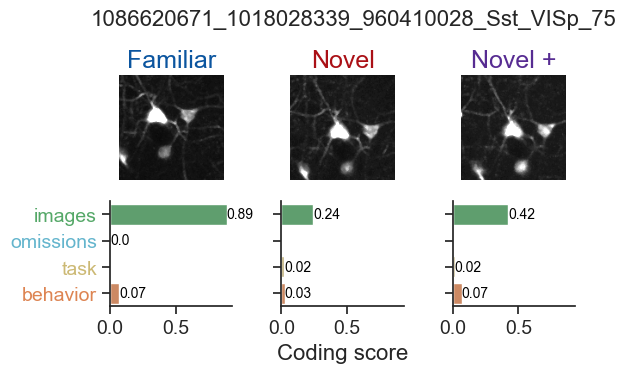

In [8]:
# Get cell response dataframes for example cell
cell_specimen_id = 1086620671  
cell_metadata = platform_cells_table[platform_cells_table.cell_specimen_id == cell_specimen_id]
cell_dropouts = results_pivoted[results_pivoted.cell_specimen_id==cell_specimen_id][processing.get_features_for_clustering()+['experience_level']]

# Load change and omission response dataframes for example cell
change_mdf_example = change_mdf[change_mdf.cell_specimen_id == cell_specimen_id]
omission_mdf_example = omission_mdf[omission_mdf.cell_specimen_id == cell_specimen_id]

# Plot matched ROI and coding scores
pse.plot_matched_roi_and_coding_scores(cell_metadata, cell_dropouts, platform_experiments, 
                                       save_dir=save_dir)
pse.plot_matched_roi_and_coding_scores_for_experience_levels(cell_metadata, cell_dropouts, platform_experiments, 
                                       save_dir=save_dir)

# # Plot cell change and omission responses
# pse.plot_cell_change_and_omission_responses(
#     change_mdf_example,
#     omission_mdf_example,
#     cell_specimen_id,
#     save_dir=save_dir)


cell_specimen_id: 1086628708
experience_level: Familiar
ophys_experiment_id: 882551935


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel
ophys_experiment_id: 882968564


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

experience_level: Novel +
ophys_experiment_id: 885146239


...

experience_level: Novel
ophys_experiment_id: 882968564


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is 

experience_level: Novel +
ophys_experiment_id: 885146239


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is 

saving plot for 1086628708
saved


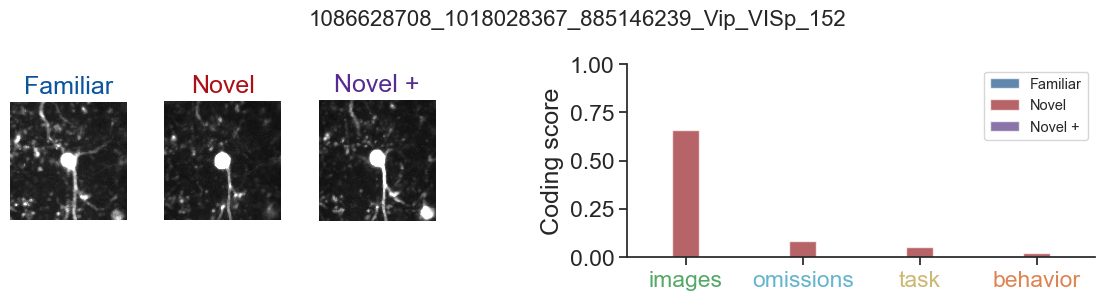

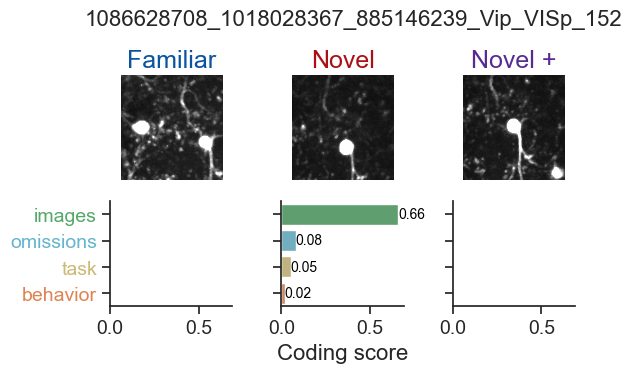

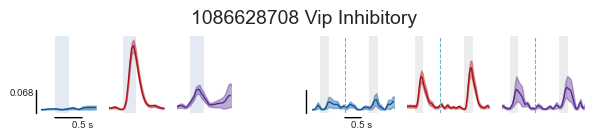

In [9]:
# Get cell response dataframes for example cell
cell_specimen_id = 1086628708  
cell_metadata = platform_cells_table[platform_cells_table.cell_specimen_id == cell_specimen_id]
cell_dropouts = results_pivoted[results_pivoted.cell_specimen_id==cell_specimen_id][processing.get_features_for_clustering()+['experience_level']]

# Load change and omission response dataframes for example cell
change_mdf_example = change_mdf[change_mdf.cell_specimen_id == cell_specimen_id]
omission_mdf_example = omission_mdf[omission_mdf.cell_specimen_id == cell_specimen_id]

# Plot matched ROI and coding scores
pse.plot_matched_roi_and_coding_scores(cell_metadata, cell_dropouts, platform_experiments, 
                                       save_dir=save_dir)
pse.plot_matched_roi_and_coding_scores_for_experience_levels(cell_metadata, cell_dropouts, platform_experiments, 
                                       save_dir=save_dir)

# Plot cell change and omission responses
pse.plot_cell_change_and_omission_responses(
    change_mdf_example,
    omission_mdf_example,
    cell_specimen_id,
    save_dir=save_dir)


## Find the 5 best example cells per cell type and plot coding scores + image-response inset
For each cell type, ranks cells by their max |coding score| (across features and experience levels),
keeping only cells with a max mean image response > 0.002 and matched across all 3 experience levels
(needed for the inset), then plots `plot_coding_scores_for_cell_with_response_inset` for the top 5.
Requires upstream vars: `results_pivoted`, `image_mdf`, `cluster_meta`, `platform_cells_table`, `platform_experiments`.
NOTE: this loads ophys datasets for every plotted cell, so the first run can be slow.

In [10]:
# --- rank cells: high |coding score| (any feature/experience level) + image response > 0.002 ---
features = processing.get_features_for_clustering()

cs = results_pivoted.copy()
cs['max_coding_score'] = cs[features].abs().max(axis=1)
cell_cs = cs.groupby('cell_specimen_id')['max_coding_score'].max()

cell_resp = image_mdf.groupby('cell_specimen_id')['mean_response'].max()

# cells matched across all 3 experience levels (needed for the F/N/N+ inset)
matched3 = image_mdf.groupby('cell_specimen_id')['experience_level'].nunique()
matched3 = matched3[matched3 == 3].index

summary = pd.concat([cell_cs, cell_resp.rename('max_image_response')], axis=1).dropna()
summary = summary[(summary.max_image_response > 0.002) & (summary.index.isin(matched3))]
summary['cell_type'] = cluster_meta.loc[summary.index, 'cell_type']

# top 5 cells per cell type, ranked by coding score
best = summary.sort_values('max_coding_score', ascending=False).groupby('cell_type').head(5)
print(best)


                  max_coding_score  max_image_response       cell_type
cell_specimen_id                                                      
1086490095                1.000000            0.004369      Excitatory
1086573206                1.000000            0.043278  Sst Inhibitory
1086573397                1.000000            0.003024      Excitatory
1086513171                1.000000            0.007960      Excitatory
1086512693                1.000000            0.002006      Excitatory
1086574338                1.000000            0.004236      Excitatory
1086575038                1.000000            0.017868  Vip Inhibitory
1086573210                1.000000            0.011329  Vip Inhibitory
1086580607                1.000000            0.030882  Sst Inhibitory
1086613911                1.000000            0.011285  Vip Inhibitory
1086615099                1.000000            0.035365  Vip Inhibitory
1086615307                1.000000            0.002641  Vip Inhibitory
108655

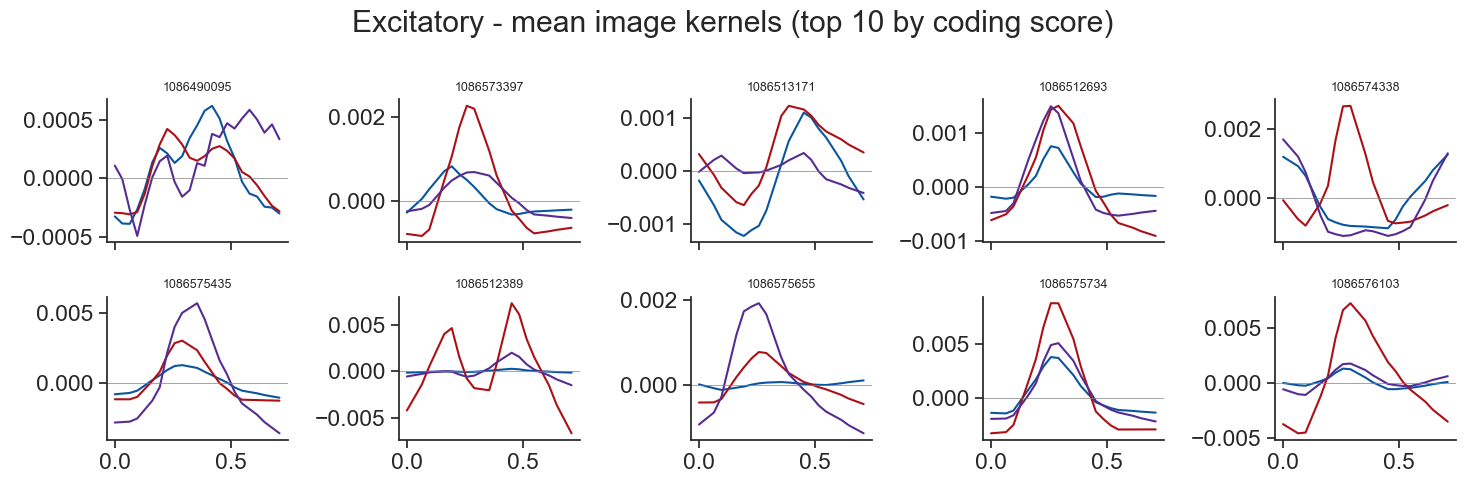

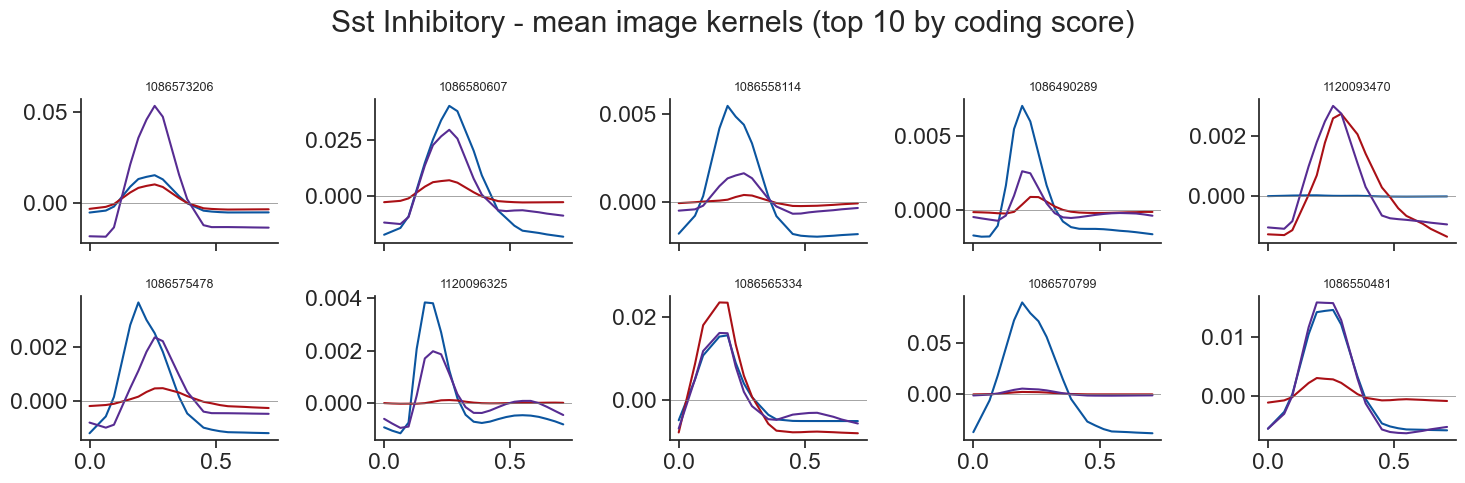

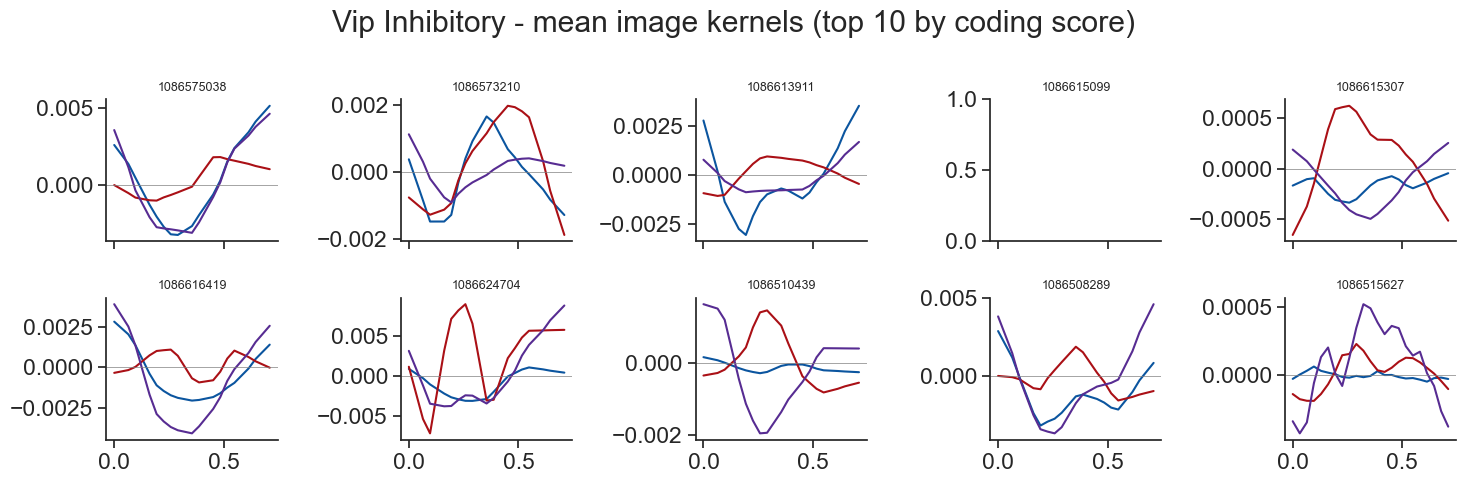

In [11]:
### plot weights for top 10 cells from each cell type
# Inspect candidate cells cheaply (no NWB download) by plotting their mean image kernels from weights_df.
# Pick the good-looking ones, then plot the coding-score + response inset only for those in the cell below.

# load GLM weights + kernels once (commented out in the setup cells above)
if 'weights_df' not in globals():
    glm_version = '24_events_all_L2_optimize_by_session'
    run_params = pd.read_pickle(os.path.join(loading.get_glm_results_dir(), glm_version + '_run_params.pkl'))
    kernels = run_params['kernels']
    weights_df = pd.read_hdf(os.path.join(loading.get_glm_results_dir(),
                                          'platform_results_weights_df.h5'), key='df')

# identify candidates (cheap): high |coding score| (any feature/exp level) + image response > 0.002,
# matched across all 3 experience levels
features = processing.get_features_for_clustering()
cs = results_pivoted.copy()
cs['max_coding_score'] = cs[features].abs().max(axis=1)
cell_cs = cs.groupby('cell_specimen_id')['max_coding_score'].max()
cell_resp = image_mdf.groupby('cell_specimen_id')['mean_response'].max()
matched3 = image_mdf.groupby('cell_specimen_id')['experience_level'].nunique()
matched3 = matched3[matched3 == 3].index
summary = pd.concat([cell_cs, cell_resp.rename('max_image_response')], axis=1).dropna()
summary = summary[(summary.max_image_response > 0.002) & (summary.index.isin(matched3))]
summary['cell_type'] = cluster_meta.loc[summary.index, 'cell_type']
candidates = summary.sort_values('max_coding_score', ascending=False).groupby('cell_type').head(10)

# image kernel columns in weights_df (image0_weights .. image7_weights)
image_features = [c[:-len('_weights')] for c in weights_df.columns
                  if c.startswith('image') and c.endswith('_weights')]
# NOTE: weights_df labels experience levels as 'Familiar'/'Novel 1'/'Novel >1' (NOT utils' 'Novel'/'Novel +');
# index-align these to the experience-level colors
weights_exp_levels = ['Familiar', 'Novel 1', 'Novel >1']
experience_level_colors = utils.get_experience_level_colors()
frame_rate = 31
t_array = pse.get_t_array_for_kernel(kernels, image_features[0], frame_rate)

# one figure per cell type; each subplot = one cell's mean image kernel across experience levels
for cell_type in candidates.cell_type.unique():
    cids = candidates[candidates.cell_type == cell_type].index.values
    fig, axes = plt.subplots(2, 5, figsize=(15, 5), sharex=True)
    axes = axes.ravel()
    for j, cell_specimen_id in enumerate(cids):
        ax = axes[j]
        cell_weights = weights_df[weights_df.cell_specimen_id == cell_specimen_id]
        for exp_level, color in zip(weights_exp_levels, experience_level_colors):
            exp_weights = cell_weights[cell_weights.experience_level == exp_level]
            if len(exp_weights) == 0:
                continue
            image_weights = [np.asarray(exp_weights[f + '_weights'].values[0]) for f in image_features]
            # skip experience levels with un-fit kernels (stored as a scalar/length-1 instead of full kernel)
            if any(iw.shape != (len(t_array),) for iw in image_weights):
                continue
            mean_image_weights = np.mean(image_weights, axis=0)
            ax.plot(t_array, mean_image_weights, color=color)
        ax.axhline(0, color='gray', lw=0.5)
        ax.set_title(str(cell_specimen_id), fontsize=9)
    for j in range(len(cids), len(axes)):
        axes[j].axis('off')
    fig.suptitle(cell_type + ' - mean image kernels (top ' + str(len(cids)) + ' by coding score)')
    fig.tight_layout()

cells to plot: [1086573397, 1086574338, 1086573206, 1086558114, 1086570799, 1086575038, 1086510439]
loading dataset 989213063 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

loading dataset 990400781 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

loading dataset 991852005 ...


...

loading dataset 877669822 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

loading dataset 877057351 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

file exists:
loading response df from file for 873970531 events images
sdf loaded
file exists:
loading response df from file for 877669822 events images
sdf loaded
file exists:
loading response df from file for 877057351 events images
sdf loaded


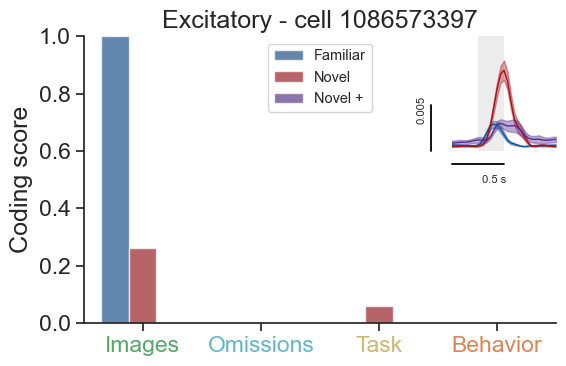

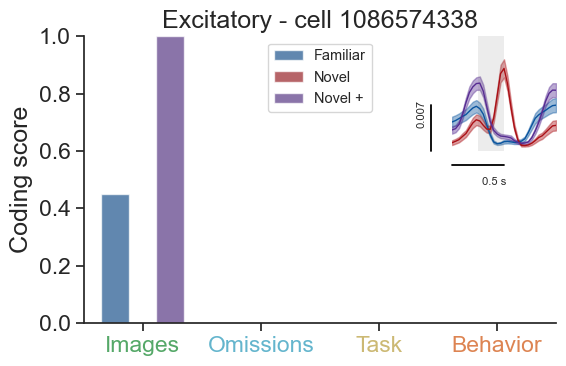

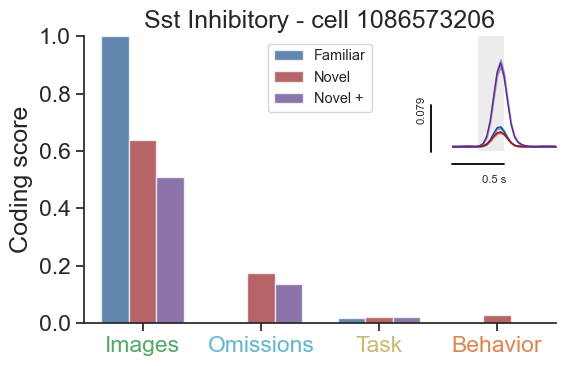

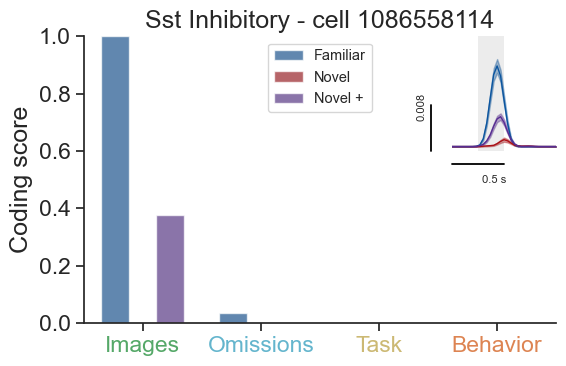

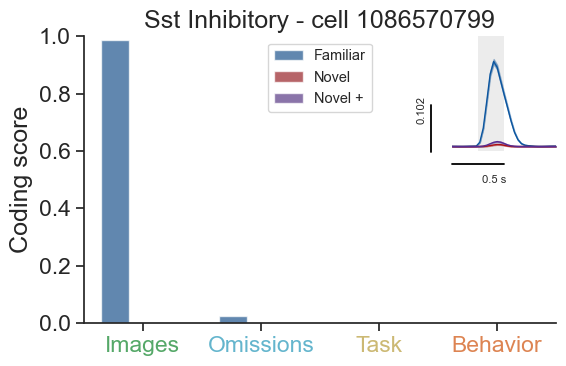

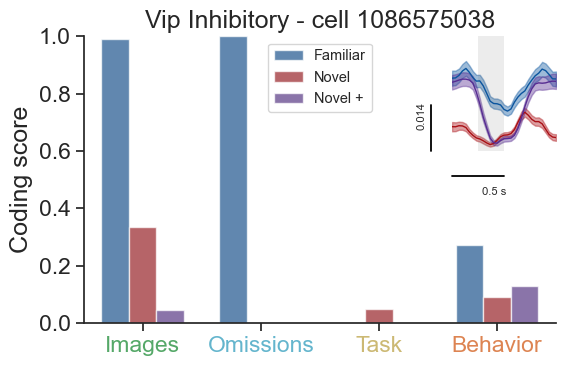

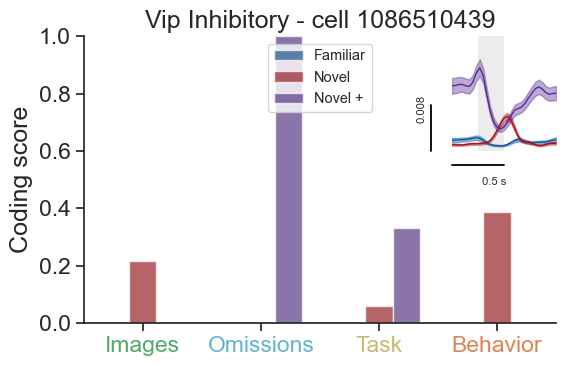

In [12]:
# --- selected example cells (by position in the weights grid, 1-indexed, ranked by coding score) ---
picks = {
    'Excitatory':     [2, 5],
    'Sst Inhibitory': [1, 3, 9],
    'Vip Inhibitory': [1, 8],
}
cells_to_plot = []
for cell_type, positions in picks.items():
    cids = candidates[candidates.cell_type == cell_type].index.values
    cells_to_plot += [int(cids[p - 1]) for p in positions]
print('cells to plot:', cells_to_plot)

# --- plot coding scores + image-response inset for each selected cell ---
SKIP_OEID = 842973730   # this experiment is very slow to load, skip any cell that includes it
datasets_cache = globals().get('_fig5_A_datasets', {})   # reuse the panel-A dataset cache
for cell_specimen_id in cells_to_plot:
    cell_type = cluster_meta.loc[cell_specimen_id, 'cell_type']
    cell_drop = results_pivoted[results_pivoted.cell_specimen_id == cell_specimen_id]   # keep ALL columns
    container = platform_cells_table[platform_cells_table.cell_specimen_id ==
                                      cell_specimen_id].ophys_container_id.unique()[0]
    oeids = platform_experiments[platform_experiments.ophys_container_id == container].index.values
    if SKIP_OEID in oeids:
        print('skipping cell', cell_specimen_id, '- associated with experiment', SKIP_OEID)
        continue
    for oeid in oeids:
        if oeid not in datasets_cache:
            print('loading dataset', oeid, '...')
            datasets_cache[oeid] = loading.get_ophys_dataset(oeid, get_extended_stimulus_presentations=False)

    fig, ax = plt.subplots(figsize=(6, 4))
    pse.plot_coding_scores_for_cell_with_response_inset(cell_drop, datasets_cache, data_type='events',
                                                        legend=True, ax=ax)
    ax.set_title(cell_type + ' - cell ' + str(cell_specimen_id))
    fig.tight_layout()
globals()['_fig5_A_datasets'] = datasets_cache

## Panel A variant: coding-score barplot with image-response inset
Demonstrates `pse.plot_coding_scores_for_cell_with_response_inset`, which draws the same
coding-score barplot as panel A but adds an inset (formatted like the cluster population-average
plots: no spines, with time + response scale bars) showing this cell's average change-triggered
response to images, overlaid across experience levels (colored by experience level).

Datasets are loaded **once** into a dict (`datasets_A`, keyed by `ophys_experiment_id`) and passed
into the function, so re-running this cell to tweak the plot does not reload them. Also note this
version needs the un-stripped per-cell rows (keep `ophys_experiment_id` / `cell_specimen_id`).
Requires the panel-A upstream vars (`A_CELL`, `results_pivoted`, `platform_cells_table`,
`platform_experiments`) from the composite cell above.

In [13]:
# other example cell options 
cell_specimen_id = 1086514606 #Excitatory behavior coding cell
cell_specimen_id = 1086620671  
cell_specimen_id = 1086628708  

# load the datasets ONCE (keyed by ophys_experiment_id) so replots don't reload them.
# reuses the composite panel-A cache (_fig5_A_datasets) if it already exists.
cell_drop_A_full = results_pivoted[results_pivoted.cell_specimen_id == A_CELL]   # keep ALL columns
container_A = platform_cells_table[platform_cells_table.cell_specimen_id == A_CELL].ophys_container_id.unique()[0]
datasets_A = globals().get('_fig5_A_datasets', {})
for oeid in platform_experiments[platform_experiments.ophys_container_id == container_A].index.values:
    if oeid not in datasets_A:
        print('loading dataset', oeid, '...')
        datasets_A[oeid] = loading.get_ophys_dataset(oeid, get_extended_stimulus_presentations=False)
globals()['_fig5_A_datasets'] = datasets_A


loading dataset 956941846 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

loading dataset 957759566 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

loading dataset 960410028 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_single_cell_examples.py:1827: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.capitalize() for label in feature_labels])


file exists:
loading response df from file for 956941846 events images
sdf loaded
file exists:
loading response df from file for 957759566 events images
sdf loaded
file exists:
loading response df from file for 960410028 events images
sdf loaded


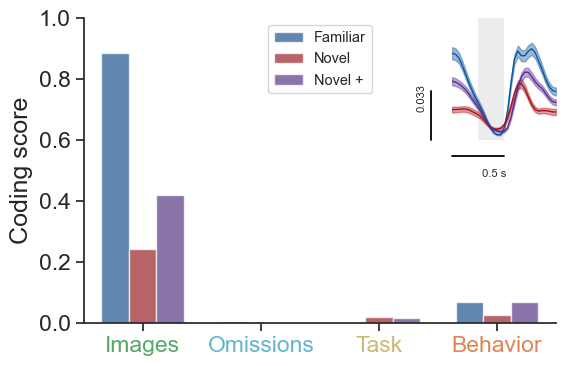

In [14]:

fig, ax = plt.subplots(figsize=(6, 4))
pse.plot_coding_scores_for_cell_with_response_inset(cell_drop_A_full, datasets_A, data_type='events', legend=True, ax=ax)
ax.set_title('')
fig.tight_layout()

In [15]:
# other example cell options 
# cell_specimen_id = 1086514606 #Excitatory behavior coding cell
# cell_specimen_id = 1086620671  
# cell_specimen_id = 1086628708  
cell_specimen_id = 1086558114 # Sst, familiar encoding

# load the datasets ONCE (keyed by ophys_experiment_id) so replots don't reload them.
# reuses the composite panel-A cache (_fig5_A_datasets) if it already exists.
cell_drop_A_full = results_pivoted[results_pivoted.cell_specimen_id == cell_specimen_id]   # keep ALL columns
container_A = platform_cells_table[platform_cells_table.cell_specimen_id == cell_specimen_id].ophys_container_id.unique()[0]
# datasets_A = globals().get('_fig5_A_datasets', {})
datasets_A = {}
for oeid in platform_experiments[platform_experiments.ophys_container_id == container_A].index.values:
    if oeid not in datasets_A:
        print('loading dataset', oeid, '...')
        datasets_A[oeid] = loading.get_ophys_dataset(oeid, get_extended_stimulus_presentations=False)
# globals()['_fig5_A_datasets'] = datasets_A


loading dataset 850517346 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

loading dataset 853363743 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

loading dataset 854759894 ...


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_single_cell_examples.py:1827: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.capitalize() for label in feature_labels])


file exists:
loading response df from file for 850517346 events images
sdf loaded
file exists:
loading response df from file for 853363743 events images
sdf loaded
file exists:
loading response df from file for 854759894 events images
sdf loaded


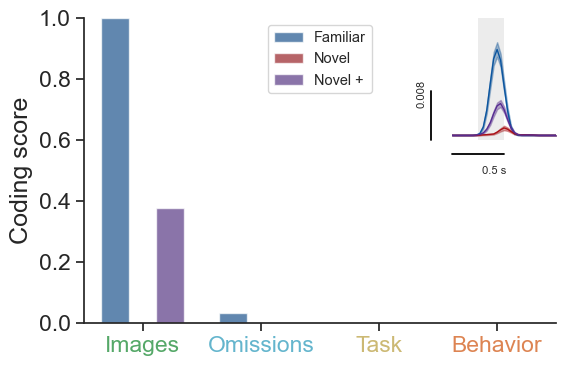

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
pse.plot_coding_scores_for_cell_with_response_inset(cell_drop_A_full, datasets_A, data_type='events', legend=True, ax=ax)
ax.set_title('')
fig.tight_layout()

In [17]:
datasets_A

{850517346: <allensdk.brain_observatory.behavior.behavior_ophys_experiment.BehaviorOphysExperiment at 0x5b9911be0>,
 853363743: <allensdk.brain_observatory.behavior.behavior_ophys_experiment.BehaviorOphysExperiment at 0x445ab7a90>,
 854759894: <allensdk.brain_observatory.behavior.behavior_ophys_experiment.BehaviorOphysExperiment at 0x43c4fcc70>}

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

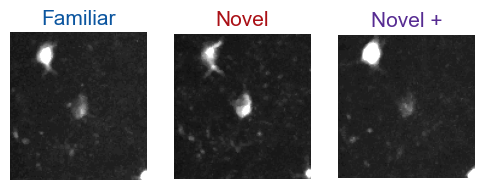

In [18]:
cell_meta_A = platform_cells_table[platform_cells_table.cell_specimen_id == cell_specimen_id]
cell_drop_A = results_pivoted[results_pivoted.cell_specimen_id == cell_specimen_id][
    processing.get_features_for_clustering() + ['experience_level']]
# container_A = cell_meta_A.ophys_container_id.unique()[0]
exp_levels_A = ['Familiar', 'Novel', 'Novel +']
exp_colors_A = utils.get_experience_level_colors()
fig, ax = plt.subplots(1, 3, figsize=(6, 4))
for e, lvl in enumerate(exp_levels_A):
    oeid = platform_experiments[(platform_experiments.ophys_container_id == container_A) &
                                (platform_experiments.experience_level == lvl)].index.values[0]
    datasets_A[oeid] = loading.get_ophys_dataset(oeid, get_extended_stimulus_presentations=False)
    ds = datasets_A[oeid]
    a = ax[e]
    # try:
    roi_id = ds.cell_specimen_table.loc[cell_specimen_id].cell_roi_id
    sf.plot_cell_zoom(ds.roi_masks, ds.max_projection, roi_id,
                        spacex=50, spacey=50, show_mask=False, ax=a)
    # except Exception:
    #     a.axis('off')
    a.set_title(lvl, color=exp_colors_A[e], fontsize=15)

## Diagnostic: un-normalized dropouts + variance_explained_full for one cell
Loads the within-session (un-normalized) dropouts from `platform_results_pivoted.h5` (which include
`variance_explained_full`), prints the scores for the cell, and remakes the coding-score + image-response
inset plot using the un-normalized dropouts. Useful for seeing why a large mean response can coincide with
a low coding score (low VE_full = the response is poorly explained by the model).

experience_level  all-images  omissions      task  behavioral  variance_explained_full
        Familiar   -1.000000   0.000000 -0.017027    0.000000                 0.213047
           Novel   -0.911703  -0.188834 -0.065341   -0.037621                 0.148503
         Novel +   -0.792744  -0.134627 -0.126313    0.000000                 0.136534
file exists:
loading response df from file for 977978331 events images


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_single_cell_examples.py:1827: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.capitalize() for label in feature_labels])


sdf loaded
file exists:
loading response df from file for 978296114 events images
sdf loaded
file exists:
loading response df from file for 981178542 events images
sdf loaded


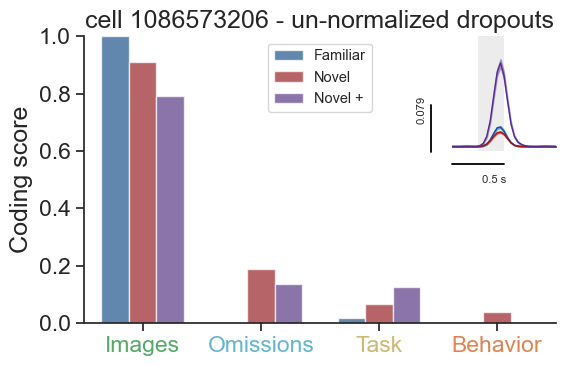

In [19]:
### un-normalized dropouts + VE_full for one cell
CELL = 1086573206

# within-session (un-normalized) dropouts include variance_explained_full
raw_results_pivoted = pd.read_hdf(os.path.join(loading.get_glm_results_dir(),
                                               'platform_results_pivoted.h5'), key='df')
cell_drop_raw = raw_results_pivoted[raw_results_pivoted.cell_specimen_id == CELL]

# print scores (raw dropouts are negative; the plot shows |dropout|)
score_cols = ['experience_level'] + processing.get_features_for_clustering() + ['variance_explained_full']
print(cell_drop_raw[score_cols].to_string(index=False))

# load datasets for this cell's container (reuse the panel-A cache)
container = platform_cells_table[platform_cells_table.cell_specimen_id == CELL].ophys_container_id.unique()[0]
datasets_cache = globals().get('_fig5_A_datasets', {})
for oeid in platform_experiments[platform_experiments.ophys_container_id == container].index.values:
    if oeid not in datasets_cache:
        print('loading dataset', oeid, '...')
        datasets_cache[oeid] = loading.get_ophys_dataset(oeid, get_extended_stimulus_presentations=False)
globals()['_fig5_A_datasets'] = datasets_cache

# coding-score + image-response inset using UN-NORMALIZED dropouts
fig, ax = plt.subplots(figsize=(6, 4))
pse.plot_coding_scores_for_cell_with_response_inset(cell_drop_raw, datasets_cache, data_type='events',
                                                    legend=True, ax=ax)
ax.set_title('cell ' + str(CELL) + ' - un-normalized dropouts')
fig.tight_layout()